Building logistic regression from scratch is like building a car engine by hand. You stop seeing "magic" and start seeing a series of mathematical gears clicking together.

Here are the six essential steps to building the intuition and the code.

---

## 1. Data Preprocessing (The Prep)

Before the math starts, the data must be in a shape the "engine" can swallow. For images, this means **Flattening** and **Normalization**.

* **Flattening:** We turn a  image into a single column of  numbers.
* **Normalization:** We divide pixel values by 255 so they range from  to .
* **Intuition:** If one feature (like house square footage) is  and another (number of bedrooms) is , the model will obsess over the  and ignore the . Normalization puts every feature on an equal playing field.

---

## 2. Initialization

We need a starting point for our weights () and bias ().

* **The Code:** Initialize  as a vector of zeros of shape  and  as .
* **Intuition:** We start with a "blank slate." Since we don't know which pixels are important yet, we treat them all as equally irrelevant (zero).

---

## 3. Forward Propagation (The Guess)

This is where the model makes a prediction. It happens in two stages:

1. **Linear Step:** Calculate the raw score, .


2. **Activation Step:** Squish that score into a probability using the Sigmoid function.


3. **Cost Calculation:** Measure how bad the guess was using the Log-Loss formula we discussed earlier.

---

## 4. Backward Propagation (The Feedback)

Now that we know how "wrong" we were (the Cost), we need to figure out how much each weight contributed to that error. This is **Calculus** in action.

We calculate the "Gradients" (the slope of the error):

* **The Error:**  (How far off was our probability from the truth?)
* **Weight Gradient ():** How much should we change ?
* **Bias Gradient ():** How much should we change ?

**Intuition:** Imagine you are on a foggy mountain (the Cost) and want to find the valley (minimum error). Backward propagation tells you which direction is "down."

---

## 5. Optimization (The Learning)

This is the only part where the model actually "learns." We use **Gradient Descent** to update the parameters.

* **The Rule:** 


* ** (Learning Rate):** This is your step size.
* Too big? You might jump over the valley.
* Too small? It will take a million years to get to the bottom.



---

## 6. Prediction

Once you have the optimized  and , you run one final forward pass.

* If , the model says "1" (Cat).
* If , the model says "0" (Non-cat).

---

### The Big Picture Table

| Step | Goal | Key Math |
| --- | --- | --- |
| **1. Flatten** | Format data | `reshape(m, -1).T` |
| **2. Init** | Start weights | `np.zeros` |
| **3. Forward** | Predict & Score |  |
| **4. Backward** | Find slopes |  |
| **5. Optimize** | Update weights |  |
| **6. Predict** | Final Decision |  |

**Would you like me to help you write the `optimize` function that loops through these steps for a set number of iterations?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Set seed for reproducibility
np.random.seed(1)


# 1. Generate 100 points for Class 0 (centered at [2, 2])
# 2. Generate 100 points for Class 1 (centered at [4, 4])
m = 200  # total examples
X_class0 = np.random.randn(2, 100) + 2
X_class1 = np.random.randn(2, 100) + 4

# Combine into one feature matrix X (2, 200)
X = np.concatenate((X_class0, X_class1), axis=1)

Y = np.concatenate((np.zeros((1, 100)), np.ones((1, 100))), axis=1)

# Shuffle the data (important so the model doesn't just see all 0s then all 1s)
permutation = np.random.permutation(m)
X = X[:, permutation]
Y = Y[:, permutation]

print("X shape:", X.shape) # (2, 200) -> 2 features (x, y coordinates), 200 examples
print("Y shape:", Y.shape) # (1, 200) -> 1 label per example


X shape: (2, 200)
Y shape: (1, 200)


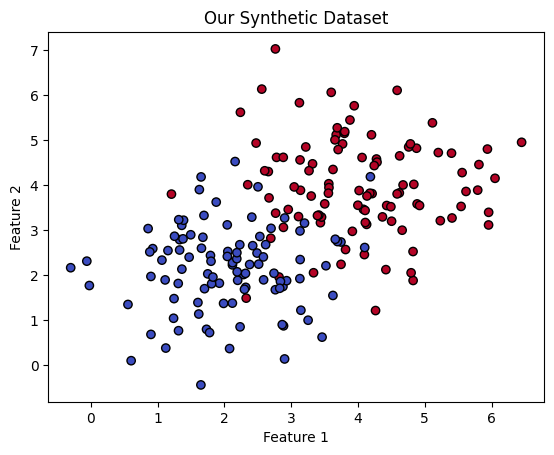

In [9]:
plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap='coolwarm', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Our Synthetic Dataset')
plt.show()

In [10]:
def initialize_with_zeros(dim):
    """
    This function creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    
    Argument:
    dim -- size of the w vector we want (in our case, 2 features)
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (corresponds to the bias)
    """
    
    w = np.zeros((dim,1))
    b = 0.
    
    return w,b 

dim = X.shape[0]
w, b = initialize_with_zeros(dim)

print("w shape:", w.shape)
print("b:", b)

w shape: (2, 1)
b: 0.0


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def propagate(w,b,X,Y):
    m = X.shape[1] # Number of examples (200)
    
    # --- FORWARD PROPAGATION
    # 1. Calculate the raw scores (Z)
    Z = np.dot(w.T,X) + b
    
    # 2. Convert scores to probabilities (A)
    A = sigmoid(Z)
    
    # 3. Calculate the Log-loss cost 
    cost = - (1 / m) * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    
    # --- BACKWARD PROPAGATION --- 
    # 4. Find the gradient (slope) for w and b
    dw = (1 / m) * np.dot(X, (A - Y).T)
    db = (1 / m) * np.sum(A - Y)
    
    # Clean up and package results 
    cost = np.squeeze(np.array(cost))
    grads = {"dw": dw, "db": db}
    
    """
    1. How wrong are we? (The cost)
    2. How should we change `w` and `b` to be less wrong? (The Gradients)

    """
    return grads, cost

In [13]:
grads, cost = propagate(w, b, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[-0.48730976]
 [-0.45671069]]
db = 0.0
cost = 0.6931471805599452


In [14]:
def optimize(w, b, X, Y, num_iterations=1000, learning_rate=0.01, print_cost=False):
    costs = []

    for i in range(num_iterations):
        # 1. Calculate gradients and cost (Forward & Backward Prop)
        grads, cost = propagate(w, b, X, Y)
        
        dw = grads["dw"]
        db = grads["db"]
        
        
        # 2. Update Rule: w = w - (learning_rate * dw)
        # This is the 'Step' down the mountain
        w = w - learning_rate * dw
        b = b - learning_rate * db 
        
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration: {i}: {cost}")
                
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    
    return params, grads, costs
            

In [15]:
# Train for 2000 steps with a learning rate of 0.005
params, grads, costs = optimize(w, b, X, Y, num_iterations=2000, learning_rate=0.005, print_cost=True)

print ("Final w = " + str(params["w"]))
print ("Final b = " + str(params["b"]))

Cost after iteration: 0: 0.6931471805599452
Cost after iteration: 100: 0.6450962471861651
Cost after iteration: 200: 0.6361243907083894
Cost after iteration: 300: 0.6276467429956107
Cost after iteration: 400: 0.6194432662537487
Cost after iteration: 500: 0.6114985686653909
Cost after iteration: 600: 0.6038000562987119
Cost after iteration: 700: 0.5963363647739038
Cost after iteration: 800: 0.5890971486093336
Cost after iteration: 900: 0.5820729166406534
Cost after iteration: 1000: 0.5752548988603645
Cost after iteration: 1100: 0.5686349388333699
Cost after iteration: 1200: 0.562205406815418
Cost after iteration: 1300: 0.5559591295629742
Cost after iteration: 1400: 0.5498893335554389
Cost after iteration: 1500: 0.5439895989625265
Cost after iteration: 1600: 0.5382538221966356
Cost after iteration: 1700: 0.5326761853074785
Cost after iteration: 1800: 0.5272511308181265
Cost after iteration: 1900: 0.5219733408803063
Final w = [[0.32466817]
 [0.18276004]]
Final b = -1.1117748915559122


In [16]:
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    
    # 1. Compute the probability vector A
    A = sigmoid(np.dot(w.T, X) + b)
    
    # 2. Convert probabilities to 0 or 1
    # if A[0,i] > 0.5, prediction is 1, else 0 
    Y_prediction = (A > 0.5).astype(int)
    
    return Y_prediction

# Get the final predictions
w_final = params["w"]
b_final = params["b"]
Y_pred = predict(w_final, b_final, X)

# Calculate Accuracy 
accuracy = 100 - np.mean(np.abs(Y_pred - Y)) * 100 
print(f"Training Accuracy: {accuracy}%")

Training Accuracy: 77.5%


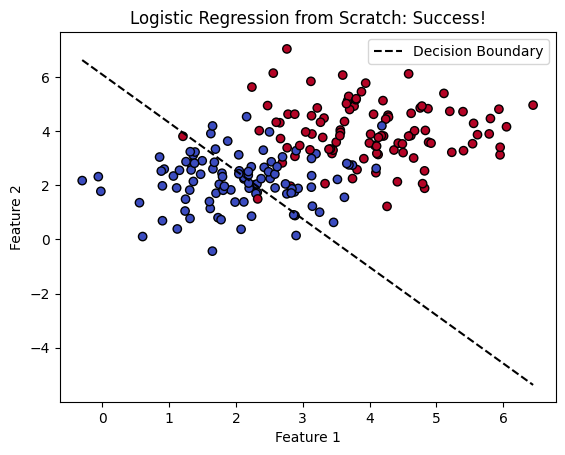

In [17]:
# Plot the data points
plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap='coolwarm', edgecolors='k')

# Calculate the decision boundary line
x_vals = np.array([np.min(X[0, :]), np.max(X[0, :])])
y_vals = -(w_final[0] * x_vals + b_final) / w_final[1]

# Plot the line
plt.plot(x_vals, y_vals, 'k--', label="Decision Boundary")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression from Scratch: Success!')
plt.legend()
plt.show()

In [ ]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model by calling the functions implemented previously
    """
    
    # 1. Initialize parameters with zeros
    w, b = initialize_with_zeros(X_train.shape[0])

    # 2. Gradient descent (Optimization)
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    # 3. Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]
    
    # 4. Predict test/train set examples
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)

    # 5. Print train/test Errors
    print(f"train accuracy: {100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100}%")
    print(f"test accuracy: {100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100}%")

    # Store everything in a dictionary
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d



In [25]:
# We have X (2, 200) and Y (1, 200) from our previous "gogoogogo" step

# 1. Define the split index (80% of 200 = 160)
train_size = 160

# 2. Slice the matrices
# Training set
X_train = X[:, :train_size]
Y_train = Y[:, :train_size]

# Test set
X_test = X[:, train_size:]
Y_test = Y[:, train_size:]

print(f"Training set shape: {X_train.shape}") # Should be (2, 160)
print(f"Test set shape: {X_test.shape}")       # Should be (2, 40)

# Now this call will actually work!
learning_rates = [0.05, 0.01, 0.001]
results = {}

for lr in learning_rates:
    print(f"\n--- Training with learning_rate: {lr} ---")
    results[str(lr)] = model(X_train, Y_train, X_test, Y_test, 
                             num_iterations=2000, learning_rate=lr, print_cost=False)

Training set shape: (2, 160)
Test set shape: (2, 40)

--- Training with learning_rate: 0.05 ---
train accuracy: 91.875%
test accuracy: 90.0%

--- Training with learning_rate: 0.01 ---
train accuracy: 87.5%
test accuracy: 80.0%

--- Training with learning_rate: 0.001 ---
train accuracy: 55.0%
test accuracy: 44.99999999999999%


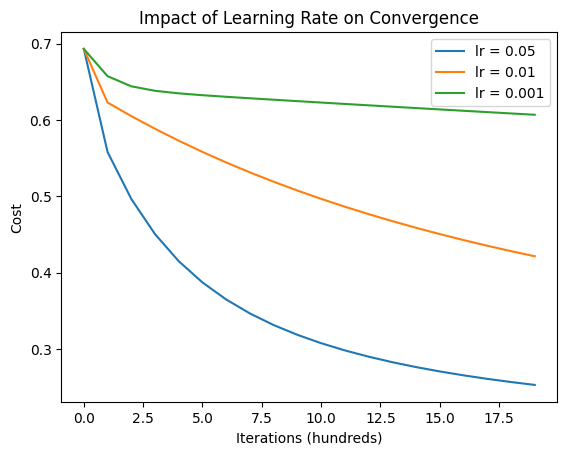

In [27]:
for lr in learning_rates:
    plt.plot(np.squeeze(results[str(lr)]["costs"]), label=f"lr = {lr}")

plt.ylabel('Cost')
plt.xlabel('Iterations (hundreds)')
plt.title("Impact of Learning Rate on Convergence")
plt.legend(loc='upper right')
plt.show()

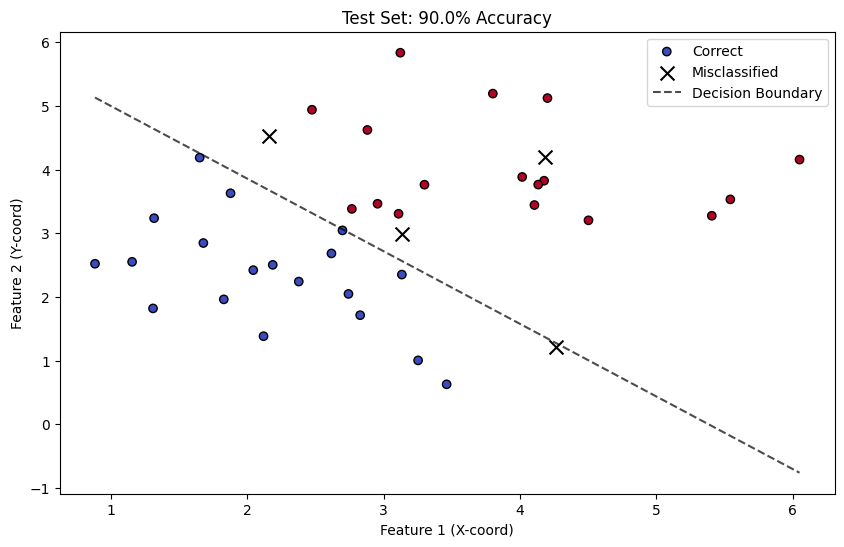

In [28]:
# 1. Get predictions and parameters from your best model
best_model = results['0.05']
w = best_model["w"]
b = best_model["b"]
Y_pred_test = best_model["Y_prediction_test"]

# 2. Identify correct and incorrect predictions
# We flatten them to make indexing easier
Y_test_flat = Y_test.ravel()
Y_pred_flat = Y_pred_test.ravel()
correct = (Y_pred_flat == Y_test_flat)
incorrect = ~correct

# 3. Plotting
plt.figure(figsize=(10, 6))

# Plot correct predictions (using their actual colors)
plt.scatter(X_test[0, correct], X_test[1, correct], c=Y_test_flat[correct], 
            cmap='coolwarm', edgecolors='k', label='Correct')

# Plot incorrect predictions (marked with a black 'X')
plt.scatter(X_test[0, incorrect], X_test[1, incorrect], c='black', 
            marker='x', s=100, label='Misclassified')

# 4. Draw the Decision Boundary Line
x_boundary = np.array([np.min(X_test[0, :]), np.max(X_test[0, :])])
y_boundary = -(w[0] * x_boundary + b) / w[1]
plt.plot(x_boundary, y_boundary, 'k--', alpha=0.7, label='Decision Boundary')

plt.xlabel('Feature 1 (X-coord)')
plt.ylabel('Feature 2 (Y-coord)')
plt.title(f'Test Set: {100 - np.mean(incorrect)*100}% Accuracy')
plt.legend()
plt.show()